In [6]:
import numpy as np 
import matplotlib.pyplot as plt

In [7]:
# Define a function to compute analytical solution to the logistic
# equation at different growth rates and carrying capacities
def y(t, N0, r=0.5, K=10.):
    """Calculate the analytical solution to the logistic equation

    Args:
        t (numpy.ndarray): time
        N0 (numpy.float64): initial population (unit: # of animals)
        r (float): growth rate (unit 1/time)
        K (float): carrying capacity (unit: # of animals)

    Returns:
        numpy.ndarray: analytical solution to the logistic equation
    """
    
    N = K / (1. - ((N0-K)/N0) * np.exp(-r*t) )
    
    return N 

In [8]:
# Define variables (only vary the initial conditions)
t = np.linspace(0,10,101)              # 101 points in time spanning [0, 10]
N0 = 2.0       # array of 10 initial conditions 
arr_r = 0.5 * np.arange(1, 5)                                # growth rate
K = 10.                                # carrying capacity

In [9]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['mathtext.default'] = 'regular'
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.titlesize'] = 20

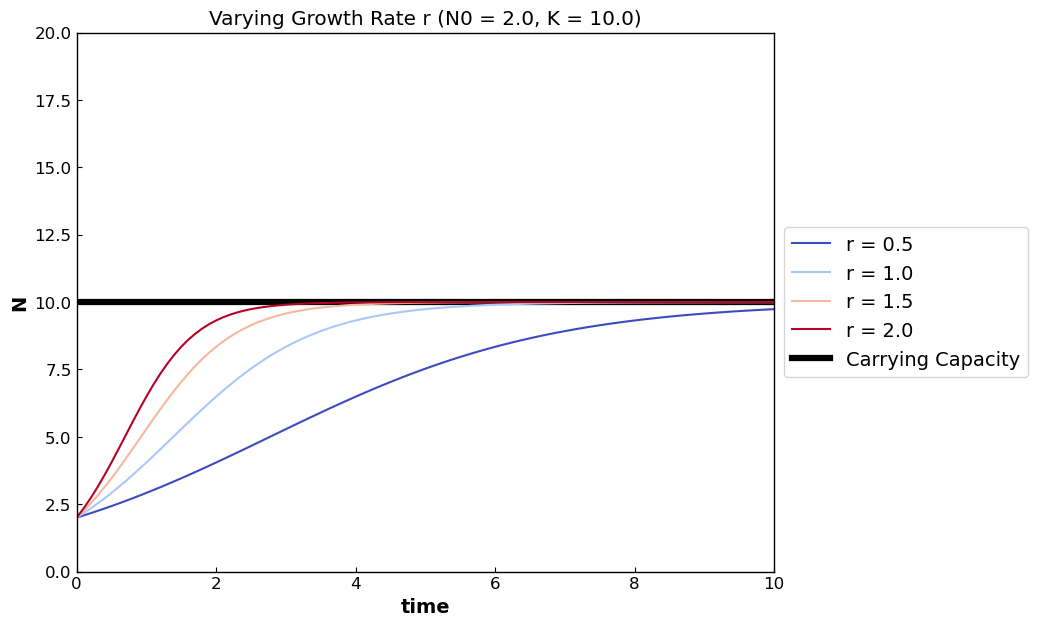

In [10]:
# Plot solutions for different initial population choices
fig, ax = plt.subplots(1,1,figsize=(9,7))

# Create a color gradient for plotting all solutions
# Check out more colormaps: https://matplotlib.org/stable/tutorials/colors/colormaps.html
n = len(arr_r) # number of solutions
colors = plt.cm.coolwarm(np.linspace(0.,1.,n))

# Loop over initial conditions and plot each solution
for idx, R in enumerate(arr_r):
    ax.plot(t, y(t, N0=N0, r=R, K=K), linewidth=1.5, color=colors[idx], label=f"r = {R:.1f}")

# Plot the carrying capacity as a reference
# zorder=0 sets the line behind the other lines
ax.plot([t.min(), t.max()], [K, K], color='k', linewidth=4.5, label='Carrying Capacity', zorder=0)   

# Set axes range
ax.set_xlim(0,10)
ax.set_ylim(0,20)

# Set axes labels and figure title
ax.set_xlabel('time')
ax.set_ylabel('N')
ax.set_title(f'Varying Growth Rate r (N0 = {N0}, K = {K})')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()